In [106]:
import numpy as np
cov = [[3, 1], [1, 2]]
mean = [0,0]
np.random.seed(42)
# random data set
x = np.random.multivariate_normal(mean, cov, 50)
print(x.shape)

(50, 2)


In [107]:
# centre the data
x_centered = x - np.mean(x, axis=0)
print(x_centered)

[[-0.98228533 -0.69863668]
 [-2.25330327  0.81168309]
 [ 0.25953573 -0.06364181]
 [-3.29355774 -0.87543631]
 [ 0.16026798  0.9483762 ]
 [ 0.77362541 -0.06597029]
 [ 0.52693206 -2.21890074]
 [ 2.8744515   1.09897208]
 [ 1.18054266  1.26342023]
 [ 2.07802852 -0.56793785]
 [-2.49596908 -1.7550833 ]
 [ 0.50724289 -1.55593462]
 [ 0.54823883  0.59164709]
 [ 1.3661156   1.46303337]
 [ 0.88809348  0.24528671]
 [-0.43522611  2.39032657]
 [ 0.41150329 -1.10787193]
 [-0.84041974 -2.10704679]
 [ 0.60915736 -2.23219195]
 [ 1.76334625  1.46138906]
 [-1.56481243 -0.63075653]
 [ 0.10917818 -0.24911364]
 [ 2.57315004  0.69501955]
 [-0.17204526  1.45410277]
 [ 0.26959568 -2.17031667]
 [-0.55042193 -0.77282448]
 [ 0.45320908  1.22494006]
 [-2.50779202 -0.16337763]
 [ 1.28494925  0.46634692]
 [-1.40295252  0.58062347]
 [ 0.62602678  0.22985703]
 [ 2.26534696 -0.15352988]
 [-2.41693382  0.48005598]
 [-0.7677396   1.01188479]
 [-0.45047043 -1.07041401]
 [-1.79934623  1.11298273]
 [-1.1730722   1.53681147]
 

In [108]:
# Creates covariance matrix of features.
cov_matrix = np.cov(x_centered, rowvar=False)
print(cov_matrix)

[[2.26032512 0.49460766]
 [0.49460766 1.59669551]]


In [109]:
eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)
print("Before sorting:", eigen_vals)
print(eigen_vecs)

Before sorting: [1.33291162 2.52410901]
[[ 0.4705787  -0.88235803]
 [-0.88235803 -0.4705787 ]]


In [110]:
#pick high value eigen vectors and eigen values

In [111]:
# Sort eigenvalues and eigenvectors
eigen_val_indices = np.argsort(eigen_vals)[::-1]
print(eigen_val_indices)

[1 0]


In [112]:
eigen_vals = eigen_vals[eigen_val_indices]
eigen_vecs = eigen_vecs[:, eigen_val_indices]
print(eigen_vals)
print(eigen_vecs)

[2.52410901 1.33291162]
[[-0.88235803  0.4705787 ]
 [-0.4705787  -0.88235803]]


In [113]:
x_pca = x_centered @ eigen_vecs

In [114]:
print(x_pca)

[[ 1.19549089  0.15420513]
 [ 1.60625945 -1.77655162]
 [-0.19905495  0.17828685]
 [ 3.31805879 -0.77742987]
 [-0.58769938 -0.76138866]
 [-0.65157038  0.42226105]
 [ 0.5792247   2.20582788]
 [-3.0534482   0.38296882]
 [-1.63619994 -0.55925075]
 [-1.56630569  1.47900048]
 [ 3.02824317  0.37406195]
 [ 0.28461986  1.6115891 ]
 [-0.76215945 -0.26405504]
 [-1.8938754  -0.64805433]
 [-0.89904311  0.20148718]
 [-0.74081152 -2.31393197]
 [ 0.15824771  1.17118437]
 [ 1.73308244  1.46368602]
 [ 0.5129271   2.25624896]
 [-2.24360128 -0.45967518]
 [ 1.6775454  -0.17981432]
 [ 0.02089333  0.27118435]
 [-2.59750099  0.59761352]
 [-0.53246427 -1.36400009]
 [ 0.78342489  2.04186232]
 [ 0.84934394  0.42289105]
 [-0.97632337 -0.86756515]
 [ 2.28965245 -1.03595595]
 [-1.35323821  0.1931848 ]
 [ 0.96467738 -1.17251735]
 [-0.66054557  0.09177867]
 [-1.92659918  1.20149235]
 [ 1.90669683 -1.56093882]
 [ 0.20124977 -1.25412657]
 [ 0.90119023  0.7325066 ]
 [ 1.06392162 -1.82878326]
 [ 0.31187892 -1.90804072]
 

In [115]:
print(x_centered[:, 0])

[-0.98228533 -2.25330327  0.25953573 -3.29355774  0.16026798  0.77362541
  0.52693206  2.8744515   1.18054266  2.07802852 -2.49596908  0.50724289
  0.54823883  1.3661156   0.88809348 -0.43522611  0.41150329 -0.84041974
  0.60915736  1.76334625 -1.56481243  0.10917818  2.57315004 -0.17204526
  0.26959568 -0.55042193  0.45320908 -2.50779202  1.28494925 -1.40295252
  0.62602678  2.26534696 -2.41693382 -0.7677396  -0.45047043 -1.79934623
 -1.1730722   3.46683595 -0.2200854   0.8158761  -0.12930811 -2.33501117
  1.35423605 -1.94836809  0.27591631 -1.01976729  1.07441513  1.27490931
 -0.90451069 -0.12732791]


In [116]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

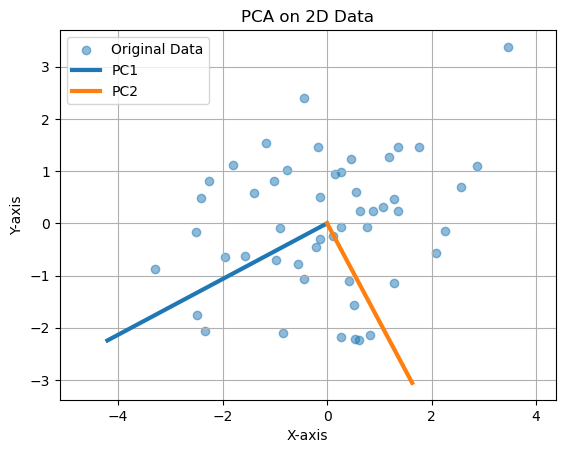

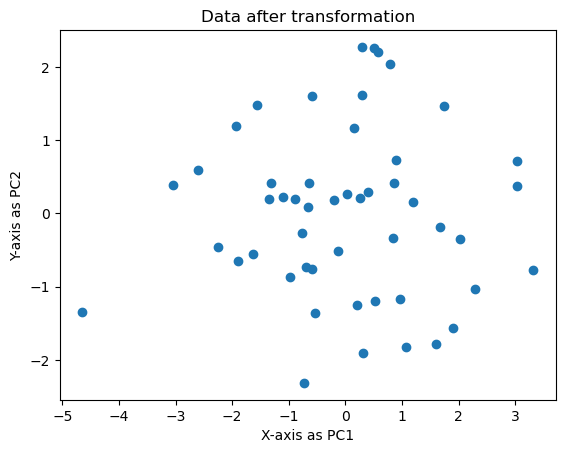

In [121]:
plt.scatter(x_centered[:, 0], x_centered[:, 1], alpha=0.5, label="Original Data")
for i in range(2):
    vec = eigen_vecs[:, i] * np.sqrt(eigen_vals[i]) * 3
    plt.plot([0, vec[0]], [0, vec[1]], linewidth=3, label=f"PC{i+1}")

plt.axis('equal')
plt.title("PCA on 2D Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)
plt.show()


plt.scatter(x_pca[:, 0], x_pca[:, 1])
plt.title("Data after transformation")
plt.xlabel("X-axis as PC1")
plt.ylabel("Y-axis as PC2")
plt.show()